In [10]:
import pandas as pd


In [11]:
df = pd.read_csv("ecommerce_customer_data_large.csv")

In [12]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  str    
 2   Product Category       250000 non-null  str    
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  str    
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  str    
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  str    
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 37.0 MB


## # Data Cleaning

## 1.Null checking

In [14]:
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [15]:
df['Returns'].dtype
                                                        

dtype('float64')

In [16]:
df['Returns'] = df['Returns'].fillna(df['Returns'].median())

In [17]:
df['Returns'].isnull().sum()

np.int64(0)

In [18]:
df.isnull().sum()

Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64

## 2. Conversion of letter and value replacement

In [19]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')

In [20]:
df.columns

Index(['customer_id', 'purchase_date', 'product_category', 'product_price',
       'quantity', 'total_purchase_amount', 'payment_method', 'customer_age',
       'returns', 'customer_name', 'age', 'gender', 'churn'],
      dtype='str')

## 3. Duplicate Cheking

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df[df.duplicated()]

,customer_id,purchase_date,product_category,product_price,quantity,total_purchase_amount,payment_method,customer_age,returns,customer_name,age,gender,churn


In [23]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

In [24]:
df['purchase_date'].dtype

dtype('<M8[us]')

## 4. Details

In [25]:
df.describe()

,customer_id,purchase_date,product_price,quantity,total_purchase_amount,customer_age,returns,age,churn
count,250000.000000,250000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.00000
mean,25017.632092,2021-11-06 19:26:22.286191,254.742724,3.004936,2725.385196,43.798276,0.595432,43.798276,0.20052
min,1.000000,2020-01-01 00:07:26,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,2020-12-03 08:10:12,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,2021-11-06 07:39:08.500000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,2022-10-11 01:21:56.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,2023-09-13 18:42:49,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000
std,14412.515718,NaN,141.738104,1.414737,1442.576095,15.364915,0.490809,15.364915,0.40039


## 5. Redundancy Removal

In [26]:
(df['customer_age'] == df['age']).mean()

np.float64(1.0)

In [27]:
df = df.drop(columns=['age'])

In [28]:
df.head()

,customer_id,purchase_date,product_category,product_price,quantity,total_purchase_amount,payment_method,customer_age,returns,customer_name,gender,churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,Female,0


## 6. Age Outliers

In [29]:
df['customer_age'].describe()

count    250000.000000
mean         43.798276
std          15.364915
min          18.000000
25%          30.000000
50%          44.000000
75%          57.000000
max          70.000000
Name: customer_age, dtype: float64

In [30]:
df['customer_age'].min(), df['customer_age'].max()

(np.int64(18), np.int64(70))

## 7.Categorical Value 

In [31]:
print(df['product_category'].unique())
print(df['payment_method'].unique())
print(df['gender'].unique())

<ArrowStringArray>
['Home', 'Electronics', 'Books', 'Clothing']
Length: 4, dtype: str
<ArrowStringArray>
['PayPal', 'Credit Card', 'Cash']
Length: 3, dtype: str
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str


## 8. Customer ID Checking & RFM Analysis

In [32]:
df['customer_id'].nunique()

49661

In [33]:
df['customer_id'].value_counts().head(10)

customer_id
48382    17
4200     16
8770     16
43126    15
12647    15
32869    15
13805    15
25927    15
35294    15
39895    15
Name: count, dtype: int64

## 9.  Churn and risk analysis

In [34]:
df['churn'].value_counts()

churn
0    199870
1     50130
Name: count, dtype: int64

In [35]:
df['churn'].value_counts(normalize=True) * 100

churn
0    79.948
1    20.052
Name: proportion, dtype: float64

## 10. Date Range

In [36]:
print("Minimum date:", df['purchase_date'].min())
print("Maximum date:", df['purchase_date'].max())

Minimum date: 2020-01-01 00:07:26
Maximum date: 2023-09-13 18:42:49


## 11. Data Type

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   customer_id            250000 non-null  int64         
 1   purchase_date          250000 non-null  datetime64[us]
 2   product_category       250000 non-null  str           
 3   product_price          250000 non-null  int64         
 4   quantity               250000 non-null  int64         
 5   total_purchase_amount  250000 non-null  int64         
 6   payment_method         250000 non-null  str           
 7   customer_age           250000 non-null  int64         
 8   returns                250000 non-null  float64       
 9   customer_name          250000 non-null  str           
 10  gender                 250000 non-null  str           
 11  churn                  250000 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(6), str(4)
memo

## 12. Categorical Value

In [38]:
print("Product Categories:")
print(df['product_category'].unique())

print("\nPayment Methods:")
print(df['payment_method'].unique())

print("\nGender:")
print(df['gender'].unique())

Product Categories:
<ArrowStringArray>
['Home', 'Electronics', 'Books', 'Clothing']
Length: 4, dtype: str

Payment Methods:
<ArrowStringArray>
['PayPal', 'Credit Card', 'Cash']
Length: 3, dtype: str

Gender:
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str


In [39]:
print("\nProduct Category Counts:")
print(df['product_category'].value_counts())

print("\nPayment Method Counts:")
print(df['payment_method'].value_counts())

print("\nGender Counts:")
print(df['gender'].value_counts())


Product Category Counts:
product_category
Electronics    62630
Clothing       62581
Home           62542
Books          62247
Name: count, dtype: int64

Payment Method Counts:
payment_method
Credit Card    83547
PayPal         83441
Cash           83012
Name: count, dtype: int64

Gender Counts:
gender
Male      125676
Female    124324
Name: count, dtype: int64


In [40]:
df['returns'].value_counts(dropna=False)

returns
1.0    148858
0.0    101142
Name: count, dtype: int64

## # Feature Engineering 

In [41]:
# Create a copy of the cleaned dataset
df_clean = df.copy()

# Check the cleaned dataset
df_clean.head()

,customer_id,purchase_date,product_category,product_price,quantity,total_purchase_amount,payment_method,customer_age,returns,customer_name,gender,churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,Female,0


In [42]:
# Check the final shape
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

Rows: 250000
Columns: 12


## 1. Make sure Purchase Date is datetime

In [43]:
# Make sure Purchase Date is in datetime format
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

print(df['purchase_date'].dtype)

datetime64[us]


## 2. Create a reference date

In [44]:
# Reference date for RFM analysis
reference_date = df['purchase_date'].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2023-09-14 18:42:49


## 3. Create RFM Feature 

In [45]:
rfm = df.groupby('customer_id').agg(
    recency=('purchase_date', lambda x: 
             (reference_date - x.max()).days),
    
    frequency=('customer_id', 'count'),
    
    monetary=('total_purchase_amount', 'sum')
).reset_index()

In [46]:
rfm.head()

,customer_id,recency,frequency,monetary
0,1,289,3,6290
1,2,73,6,16481
2,3,223,4,9423
3,4,442,5,7826
4,5,425,5,9769


## 4. Average Order Value 

In [47]:
rfm['avg_order_value'] = (
    rfm['monetary'] / rfm['frequency']
)

In [48]:
rfm.head()

,customer_id,recency,frequency,monetary,avg_order_value
0,1,289,3,6290,2096.666667
1,2,73,6,16481,2746.833333
2,3,223,4,9423,2355.750000
3,4,442,5,7826,1565.200000
4,5,425,5,9769,1953.800000


## 5. Total Quantity Purchased

In [49]:
total_quantity = df.groupby('customer_id')['quantity'].sum().reset_index()

total_quantity.rename(
    columns={'quantity': 'total_quantity'},
    inplace=True
)

rfm = rfm.merge(total_quantity, on='customer_id', how='left')

In [50]:
rfm.head()

,customer_id,recency,frequency,monetary,avg_order_value,total_quantity
0,1,289,3,6290,2096.666667,15
1,2,73,6,16481,2746.833333,18
2,3,223,4,9423,2355.750000,15
3,4,442,5,7826,1565.200000,19
4,5,425,5,9769,1953.800000,13


## 6. Return Date

In [51]:
return_rate = df.groupby('customer_id')['returns'].mean().reset_index()

return_rate.rename(
    columns={'returns': 'return_rate'},
    inplace=True
)

rfm = rfm.merge(return_rate, on='customer_id', how='left')

In [52]:
rfm['return_rate_pct'] = rfm['return_rate'] * 100

In [53]:
rfm.head()

,customer_id,recency,frequency,monetary,avg_order_value,total_quantity,return_rate,return_rate_pct
0,1,289,3,6290,2096.666667,15,0.666667,66.666667
1,2,73,6,16481,2746.833333,18,0.666667,66.666667
2,3,223,4,9423,2355.750000,15,0.750000,75.000000
3,4,442,5,7826,1565.200000,19,0.600000,60.000000
4,5,425,5,9769,1953.800000,13,1.000000,100.000000


## 7. Purchase Span

In [54]:
purchase_span = df.groupby('customer_id')['purchase_date'].agg(
    first_purchase='min',
    last_purchase='max'
).reset_index()

purchase_span['purchase_span_days'] = (
    purchase_span['last_purchase'] -
    purchase_span['first_purchase']
).dt.days

rfm = rfm.merge(purchase_span, on='customer_id', how='left')

In [55]:
rfm.head()

,customer_id,recency,frequency,monetary,avg_order_value,total_quantity,return_rate,return_rate_pct,first_purchase,last_purchase,purchase_span_days
0,1,289,3,6290,2096.666667,15,0.666667,66.666667,2020-03-04 10:26:02,2022-11-29 06:48:25,999
1,2,73,6,16481,2746.833333,18,0.666667,66.666667,2020-07-31 16:27:41,2023-07-03 17:26:19,1067
2,3,223,4,9423,2355.750000,15,0.750000,75.000000,2020-01-19 00:03:00,2023-02-03 03:58:07,1111
3,4,442,5,7826,1565.200000,19,0.600000,60.000000,2020-10-12 22:03:10,2022-06-29 03:41:09,624
4,5,425,5,9769,1953.800000,13,1.000000,100.000000,2020-04-08 21:57:19,2022-07-16 04:08:09,828


## 8. Number of Product Categories Purchased

In [56]:
category_count = df.groupby('customer_id')['product_category'].nunique().reset_index()

category_count.rename(
    columns={'product_category': 'category_count'},
    inplace=True
)

rfm = rfm.merge(category_count, on='customer_id', how='left')

## 9. Add Customer Demographics

In [57]:
customer_profile = df.groupby('customer_id').agg(
    customer_age=('customer_age', 'first'),
    gender=('gender', 'first'),
    churn=('churn', 'first')
).reset_index()

rfm = rfm.merge(customer_profile, on='customer_id', how='left')

In [58]:
rfm.head()

,customer_id,recency,frequency,monetary,avg_order_value,total_quantity,return_rate,return_rate_pct,first_purchase,last_purchase,purchase_span_days,category_count,customer_age,gender,churn
0,1,289,3,6290,2096.666667,15,0.666667,66.666667,2020-03-04 10:26:02,2022-11-29 06:48:25,999,3,67,Female,0
1,2,73,6,16481,2746.833333,18,0.666667,66.666667,2020-07-31 16:27:41,2023-07-03 17:26:19,1067,4,42,Female,0
2,3,223,4,9423,2355.750000,15,0.750000,75.000000,2020-01-19 00:03:00,2023-02-03 03:58:07,1111,3,31,Male,0
3,4,442,5,7826,1565.200000,19,0.600000,60.000000,2020-10-12 22:03:10,2022-06-29 03:41:09,624,4,37,Male,0
4,5,425,5,9769,1953.800000,13,1.000000,100.000000,2020-04-08 21:57:19,2022-07-16 04:08:09,828,2,24,Female,0


In [59]:
print("Rows:", rfm.shape[0])
print("Columns:", rfm.shape[1])

Rows: 49661
Columns: 15


In [60]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 49661 entries, 0 to 49660
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         49661 non-null  int64         
 1   recency             49661 non-null  int64         
 2   frequency           49661 non-null  int64         
 3   monetary            49661 non-null  int64         
 4   avg_order_value     49661 non-null  float64       
 5   total_quantity      49661 non-null  int64         
 6   return_rate         49661 non-null  float64       
 7   return_rate_pct     49661 non-null  float64       
 8   first_purchase      49661 non-null  datetime64[us]
 9   last_purchase       49661 non-null  datetime64[us]
 10  purchase_span_days  49661 non-null  int64         
 11  category_count      49661 non-null  int64         
 12  customer_age        49661 non-null  int64         
 13  gender              49661 non-null  str           
 14  c

## # EDA

## 1. Basic Transactions detail

In [61]:
print("Total Transactions:", len(df))
print("Unique Customers:", df['customer_id'].nunique())
print("Total Revenue:", df['total_purchase_amount'].sum())
print("Average Purchase Amount:", df['total_purchase_amount'].mean())
print("Average Quantity:", df['quantity'].mean())

Total Transactions: 250000
Unique Customers: 49661
Total Revenue: 681346299
Average Purchase Amount: 2725.385196
Average Quantity: 3.004936


## 2. Customer Age Distribution

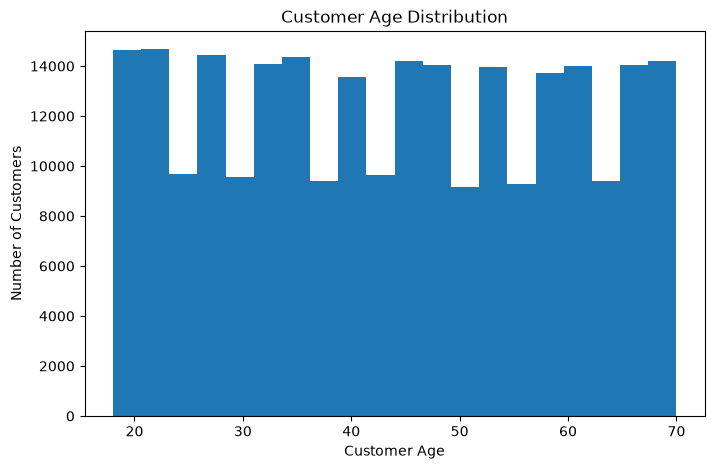

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['customer_age'], bins=20)

plt.title('Customer Age Distribution')
plt.xlabel('Customer Age')
plt.ylabel('Number of Customers')

plt.show()

## 3. Revenue by product category

In [63]:
category_revenue = (
    df.groupby('product_category')['total_purchase_amount']
      .sum()
      .sort_values(ascending=False)
)

print(category_revenue)

product_category
Home           171138916
Clothing       170716122
Electronics    170146025
Books          169345236
Name: total_purchase_amount, dtype: int64


## Visualisation

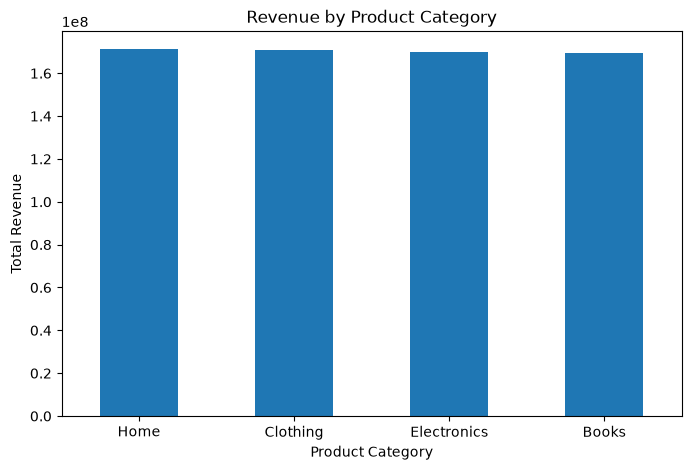

In [64]:
plt.figure(figsize=(8,5))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)

plt.show()

## 4. Purchase Quantity by category

In [65]:
category_quantity = (
    df.groupby('product_category')['quantity']
      .sum()
      .sort_values(ascending=False)
)

print(category_quantity)

product_category
Clothing       188688
Home           188077
Electronics    187861
Books          186608
Name: quantity, dtype: int64


## Visualisation 

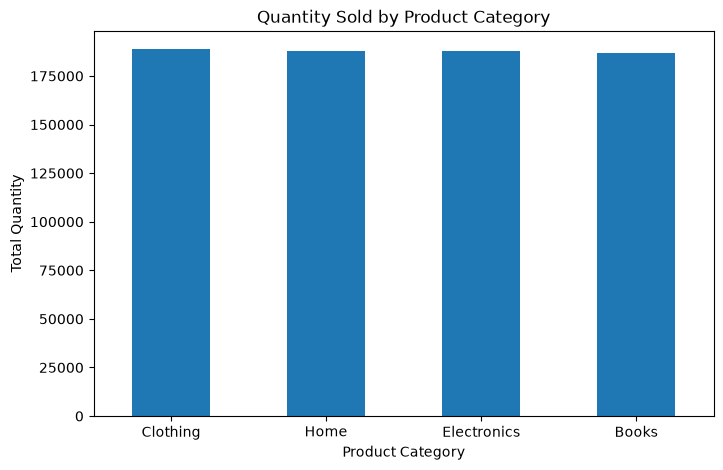

In [66]:
plt.figure(figsize=(8,5))

category_quantity.plot(kind='bar')

plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity')
plt.xticks(rotation=0)

plt.show()

## 5. Payment Method Analysis 

In [67]:
payment_counts = df['payment_method'].value_counts()

print(payment_counts)

payment_method
Credit Card    83547
PayPal         83441
Cash           83012
Name: count, dtype: int64


## Visualisation 

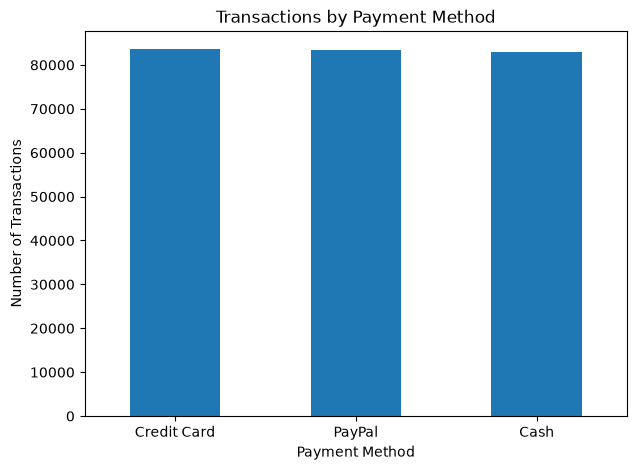

In [68]:
plt.figure(figsize=(7,5))

payment_counts.plot(kind='bar')

plt.title('Transactions by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)

plt.show()

## 6. Gender Wise Spending 

In [69]:
gender_revenue = (
    df.groupby('gender')['total_purchase_amount']
      .sum()
)

print(gender_revenue)

gender
Female    338559456
Male      342786843
Name: total_purchase_amount, dtype: int64


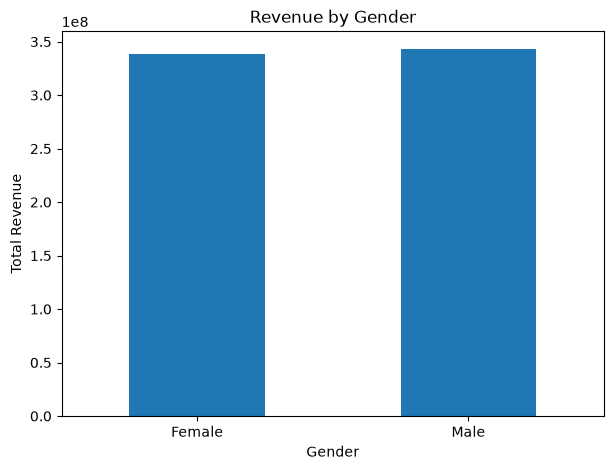

In [70]:
plt.figure(figsize=(7,5))

gender_revenue.plot(kind='bar')

plt.title('Revenue by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)

plt.show()

## 7. Monthly Purchase Trend

In [71]:
df['purchase_month'] = df['purchase_date'].dt.to_period('M')

In [72]:
monthly_revenue = (
    df.groupby('purchase_month')['total_purchase_amount']
      .sum()
)

## Visualisation

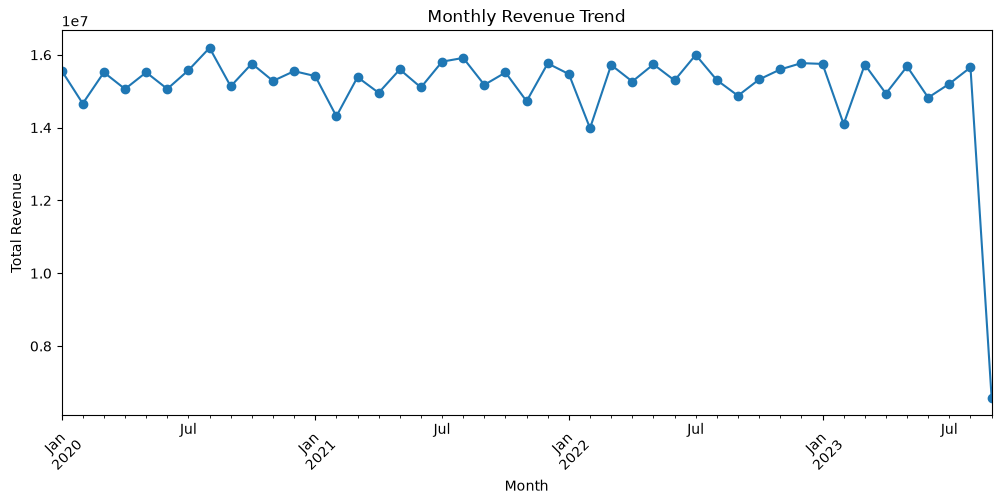

In [73]:
plt.figure(figsize=(12,5))

monthly_revenue.plot(kind='line', marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.show()

## 8. Return Analysis 

In [74]:
return_rate = df['returns'].mean() * 100

print(f"Overall Return Rate: {return_rate:.2f}%")

Overall Return Rate: 59.54%


In [75]:
category_returns = (
    df.groupby('product_category')['returns']
      .mean() * 100
)

print(category_returns)

product_category
Books          59.816537
Clothing       59.329509
Electronics    59.674278
Home           59.353714
Name: returns, dtype: float64


## Visualisation

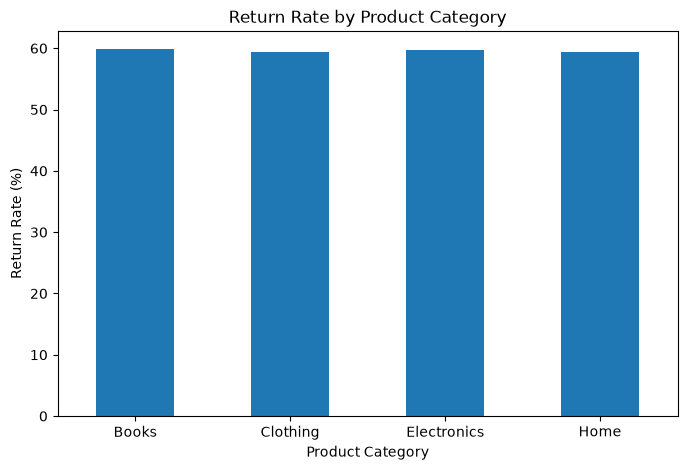

In [76]:
plt.figure(figsize=(8,5))

category_returns.plot(kind='bar')

plt.title('Return Rate by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=0)

plt.show()

## 9. Churn Analysis

In [77]:
churn_counts = df['churn'].value_counts()

print(churn_counts)

churn
0    199870
1     50130
Name: count, dtype: int64


In [78]:
churn_percentage = df['churn'].value_counts(normalize=True) * 100

print(churn_percentage)

churn
0    79.948
1    20.052
Name: proportion, dtype: float64


## Visualisation

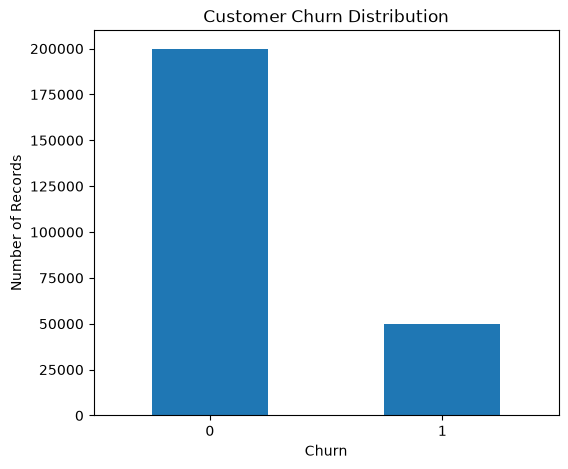

In [79]:
plt.figure(figsize=(6,5))

churn_counts.plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)

plt.show()

## 10. Purchase Amount Distribution

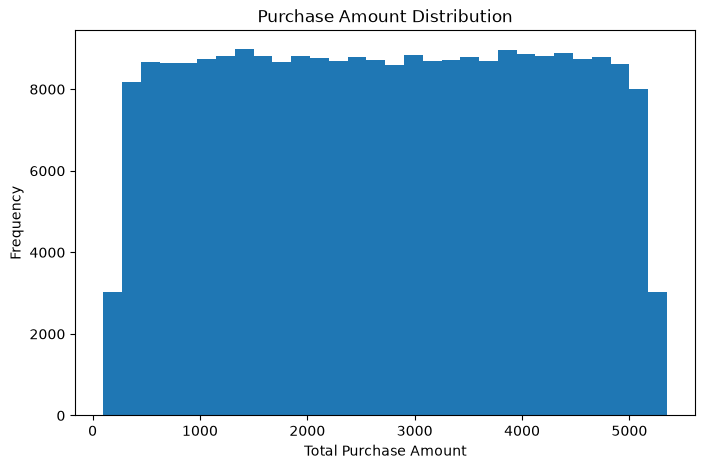

In [80]:
plt.figure(figsize=(8,5))

plt.hist(df['total_purchase_amount'], bins=30)

plt.title('Purchase Amount Distribution')
plt.xlabel('Total Purchase Amount')
plt.ylabel('Frequency')

plt.show()

## 11. Correlation Analysis

In [81]:
numeric_cols = [
    'product_price',
    'quantity',
    'total_purchase_amount',
    'customer_age',
    'returns',
    'churn'
]

correlation = df[numeric_cols].corr()

print(correlation)

                       product_price  quantity  total_purchase_amount  \
product_price               1.000000  0.002339              -0.001297   
quantity                    0.002339  1.000000               0.001234   
total_purchase_amount      -0.001297  0.001234               1.000000   
customer_age                0.002214 -0.000180               0.056552   
returns                     0.002417 -0.001099               0.000593   
churn                       0.001181 -0.001352               0.000706   

                       customer_age   returns     churn  
product_price              0.002214  0.002417  0.001181  
quantity                  -0.000180 -0.001099 -0.001352  
total_purchase_amount      0.056552  0.000593  0.000706  
customer_age               1.000000 -0.002390 -0.002299  
returns                   -0.002390  1.000000 -0.004539  
churn                     -0.002299 -0.004539  1.000000  


## Visualize

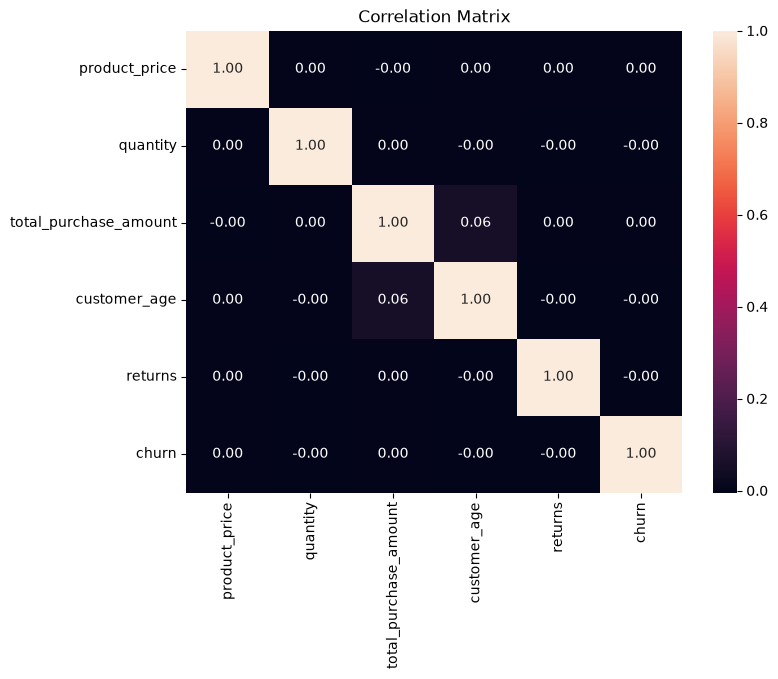

In [82]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

## # RFM Analaysis & Customer Segmentation

## 1. Check the RFM data

In [83]:
rfm.head()

,customer_id,recency,frequency,monetary,avg_order_value,total_quantity,return_rate,return_rate_pct,first_purchase,last_purchase,purchase_span_days,category_count,customer_age,gender,churn
0,1,289,3,6290,2096.666667,15,0.666667,66.666667,2020-03-04 10:26:02,2022-11-29 06:48:25,999,3,67,Female,0
1,2,73,6,16481,2746.833333,18,0.666667,66.666667,2020-07-31 16:27:41,2023-07-03 17:26:19,1067,4,42,Female,0
2,3,223,4,9423,2355.750000,15,0.750000,75.000000,2020-01-19 00:03:00,2023-02-03 03:58:07,1111,3,31,Male,0
3,4,442,5,7826,1565.200000,19,0.600000,60.000000,2020-10-12 22:03:10,2022-06-29 03:41:09,624,4,37,Male,0
4,5,425,5,9769,1953.800000,13,1.000000,100.000000,2020-04-08 21:57:19,2022-07-16 04:08:09,828,2,24,Female,0


In [84]:
rfm[['recency', 'frequency', 'monetary']].describe()

,recency,frequency,monetary
count,49661.000000,49661.000000,49661.000000
mean,262.335374,5.034131,13719.947222
std,246.804539,2.199399,6811.065854
min,1.000000,1.000000,125.000000
25%,78.000000,3.000000,8718.000000
50%,187.000000,5.000000,13008.000000
75%,371.000000,6.000000,17921.000000
max,1352.000000,17.000000,50659.000000


## 2. Create RFM Score 

In [85]:
## Recency Score 
rfm['R_score'] = pd.qcut(
    rfm['recency'],
    5,
    labels=[5, 4, 3, 2, 1]
)

In [86]:
## Frequency Score
rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [87]:
## Monetary Score
rfm['M_score'] = pd.qcut(
    rfm['monetary'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [88]:
rfm.head()

,customer_id,recency,frequency,monetary,avg_order_value,total_quantity,return_rate,return_rate_pct,first_purchase,last_purchase,purchase_span_days,category_count,customer_age,gender,churn,R_score,F_score,M_score
0,1,289,3,6290,2096.666667,15,0.666667,66.666667,2020-03-04 10:26:02,2022-11-29 06:48:25,999,3,67,Female,0,2,1,1
1,2,73,6,16481,2746.833333,18,0.666667,66.666667,2020-07-31 16:27:41,2023-07-03 17:26:19,1067,4,42,Female,0,4,4,4
2,3,223,4,9423,2355.750000,15,0.750000,75.000000,2020-01-19 00:03:00,2023-02-03 03:58:07,1111,3,31,Male,0,3,2,2
3,4,442,5,7826,1565.200000,19,0.600000,60.000000,2020-10-12 22:03:10,2022-06-29 03:41:09,624,4,37,Male,0,1,3,2
4,5,425,5,9769,1953.800000,13,1.000000,100.000000,2020-04-08 21:57:19,2022-07-16 04:08:09,828,2,24,Female,0,2,3,2


## 3. Convert scores to integer 

In [89]:
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

## 4. Create the RFM Score 

In [90]:
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [91]:
rfm.head()

,customer_id,recency,frequency,monetary,avg_order_value,total_quantity,return_rate,return_rate_pct,first_purchase,last_purchase,purchase_span_days,category_count,customer_age,gender,churn,R_score,F_score,M_score,RFM_score
0,1,289,3,6290,2096.666667,15,0.666667,66.666667,2020-03-04 10:26:02,2022-11-29 06:48:25,999,3,67,Female,0,2,1,1,211
1,2,73,6,16481,2746.833333,18,0.666667,66.666667,2020-07-31 16:27:41,2023-07-03 17:26:19,1067,4,42,Female,0,4,4,4,444
2,3,223,4,9423,2355.750000,15,0.750000,75.000000,2020-01-19 00:03:00,2023-02-03 03:58:07,1111,3,31,Male,0,3,2,2,322
3,4,442,5,7826,1565.200000,19,0.600000,60.000000,2020-10-12 22:03:10,2022-06-29 03:41:09,624,4,37,Male,0,1,3,2,132
4,5,425,5,9769,1953.800000,13,1.000000,100.000000,2020-04-08 21:57:19,2022-07-16 04:08:09,828,2,24,Female,0,2,3,2,232


## 5. Create Overall RFM score 

In [92]:
rfm['RFM_average'] = (
    rfm['R_score'] +
    rfm['F_score'] +
    rfm['M_score']
) / 3

In [93]:
## Check
rfm[['customer_id',
     'recency',
     'frequency',
     'monetary',
     'R_score',
     'F_score',
     'M_score',
     'RFM_score',
     'RFM_average']].head(10)

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,RFM_average
0,1,289,3,6290,2,1,1,211,1.333333
1,2,73,6,16481,4,4,4,444,4.000000
2,3,223,4,9423,3,2,2,322,2.333333
3,4,442,5,7826,1,3,2,132,2.000000
4,5,425,5,9769,2,3,2,232,2.333333
5,6,141,9,25428,3,5,5,355,4.333333
6,7,142,8,17825,3,5,4,354,4.000000
7,8,26,7,16245,5,4,4,544,4.333333
8,9,141,7,24621,3,4,5,345,4.000000
9,10,131,8,20672,4,5,5,455,4.666667


## 6. Create Customer Segments

In [94]:
def segment_customer(row):
    
    if row['RFM_average'] >= 4.5:
        return 'Champions'
    
    elif row['RFM_average'] >= 3.5:
        return 'Loyal Customers'
    
    elif row['RFM_average'] >= 2.5:
        return 'Potential Loyalists'
    
    elif row['RFM_average'] >= 1.5:
        return 'At Risk'
    
    else:
        return 'Hibernating'

In [95]:
rfm['segment'] = rfm.apply(segment_customer, axis=1)

## 7. Check Segment Distribution

In [96]:
segment_counts = rfm['segment'].value_counts()

print(segment_counts)

segment
Potential Loyalists    13452
Loyal Customers        12932
At Risk                11443
Hibernating             6282
Champions               5552
Name: count, dtype: int64


In [97]:
## Percentage
segment_percentage = (
    rfm['segment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(segment_percentage)

segment
Potential Loyalists    27.09
Loyal Customers        26.04
At Risk                23.04
Hibernating            12.65
Champions              11.18
Name: proportion, dtype: float64


## 8. Visualize customer segments

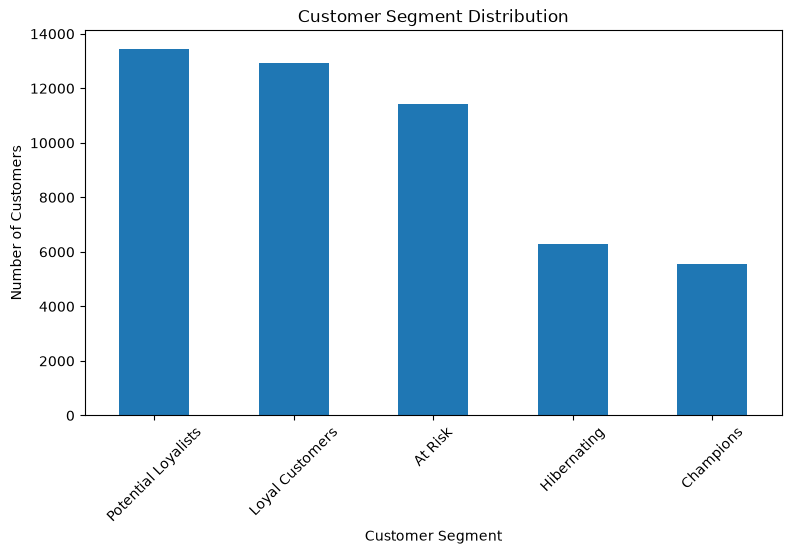

In [98]:
plt.figure(figsize=(9,5))

rfm['segment'].value_counts().plot(kind='bar')

plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

plt.show()

## 9. Profile the segments 

In [99]:
segment_profile = rfm.groupby('segment').agg(
    customers=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    avg_order_value=('avg_order_value', 'mean'),
    avg_return_rate=('return_rate_pct', 'mean')
).round(2)

segment_profile

,customers,avg_recency,avg_frequency,avg_monetary,avg_order_value,avg_return_rate
segment,,,,,,
At Risk,11443,331.94,3.46,8847.90,2615.84,59.39
Champions,5552,52.96,8.31,23839.70,2897.04,59.49
Hibernating,6282,654.15,2.18,5338.36,2535.99,59.30
Loyal Customers,12932,148.15,6.63,18546.56,2832.45,59.75
Potential Loyalists,13452,216.34,4.83,12961.80,2739.55,59.56


## 10. Revenue Contribtion by Segment

In [100]:
segment_revenue = (
    rfm.groupby('segment')['monetary']
       .sum()
       .sort_values(ascending=False)
)

segment_revenue

segment
Loyal Customers        239844107
Potential Loyalists    174362083
Champions              132357994
At Risk                101246555
Hibernating             33535560
Name: monetary, dtype: int64

In [101]:
## Percentage COntibution 
segment_revenue_percentage = (
    segment_revenue /
    segment_revenue.sum() * 100
).round(2)

segment_revenue_percentage

segment
Loyal Customers        35.20
Potential Loyalists    25.59
Champions              19.43
At Risk                14.86
Hibernating             4.92
Name: monetary, dtype: float64

## Visualize

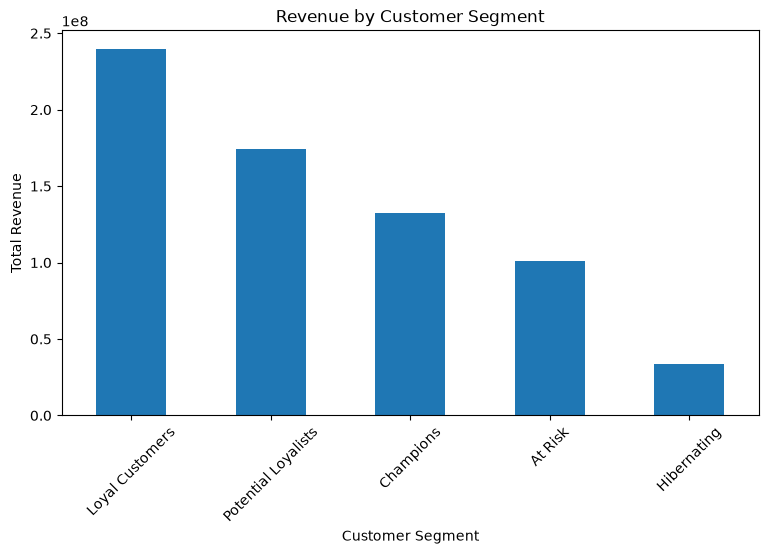

In [102]:
plt.figure(figsize=(9,5))

segment_revenue.plot(kind='bar')

plt.title('Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.show()

## # K Means Customer Segmentation

## 1. Select RFM Features 

In [103]:
# Select features for K-Means
kmeans_data = rfm[['recency', 'frequency', 'monetary']].copy()

kmeans_data.head()

,recency,frequency,monetary
0,289,3,6290
1,73,6,16481
2,223,4,9423
3,442,5,7826
4,425,5,9769


## 2. Check the distribution

In [104]:
kmeans_data.describe()

,recency,frequency,monetary
count,49661.000000,49661.000000,49661.000000
mean,262.335374,5.034131,13719.947222
std,246.804539,2.199399,6811.065854
min,1.000000,1.000000,125.000000
25%,78.000000,3.000000,8718.000000
50%,187.000000,5.000000,13008.000000
75%,371.000000,6.000000,17921.000000
max,1352.000000,17.000000,50659.000000


## 3. Standardize the data

In [105]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

kmeans_scaled = scaler.fit_transform(kmeans_data)

## 4. Find the optimal number of clusters — Elbow Method

In [106]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(kmeans_scaled)
    inertia.append(kmeans.inertia_)

## Visualisation

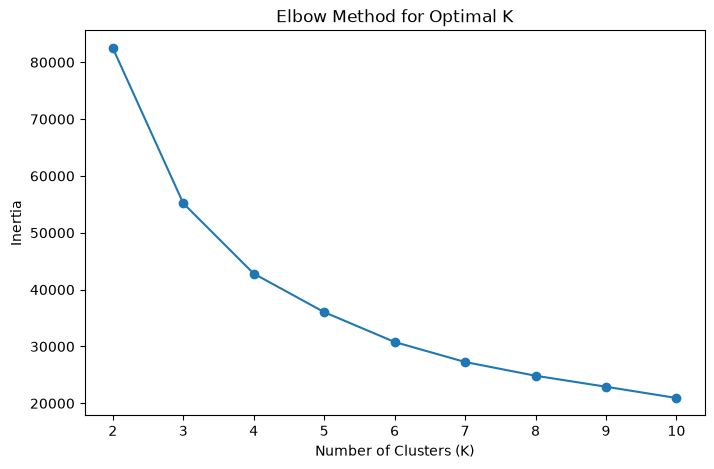

In [107]:
plt.figure(figsize=(8,5))

plt.plot(range(2, 11), inertia, marker='o')

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.show()

## 5. Silhouette Score

In [108]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(kmeans_scaled)
    
    score = silhouette_score(kmeans_scaled, labels)
    silhouette_scores.append(score)
    
    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.379
K = 3, Silhouette Score = 0.375
K = 4, Silhouette Score = 0.329
K = 5, Silhouette Score = 0.335
K = 6, Silhouette Score = 0.310
K = 7, Silhouette Score = 0.300
K = 8, Silhouette Score = 0.276
K = 9, Silhouette Score = 0.280
K = 10, Silhouette Score = 0.286


## Visualization

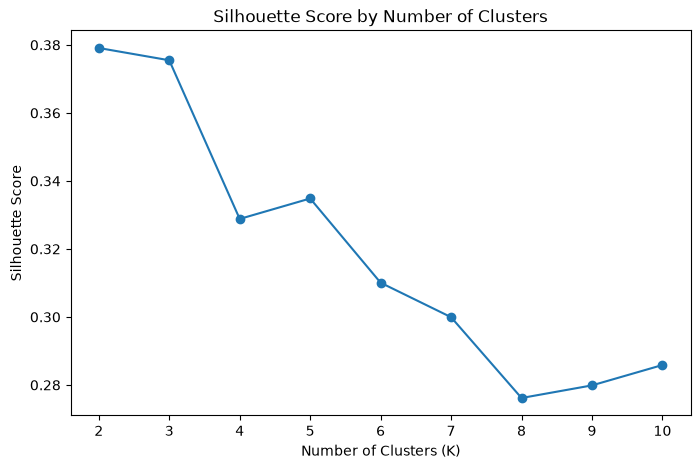

In [109]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.show()

##  6. Choose k 

In [110]:
optimal_k = 2

## 7. Apply K means

In [111]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['cluster'] = kmeans.fit_predict(kmeans_scaled)

In [112]:
rfm['cluster'].value_counts().sort_index()

cluster
0    26908
1    22753
Name: count, dtype: int64

## 8. Profile the Cluster 

In [113]:
cluster_profile = rfm.groupby('cluster').agg(
    customers=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    avg_order_value=('avg_order_value', 'mean'),
    avg_return_rate=('return_rate_pct', 'mean'),
    churn_rate=('churn', 'mean')
).round(2)

cluster_profile

,customers,avg_recency,avg_frequency,avg_monetary,avg_order_value,avg_return_rate,churn_rate
cluster,,,,,,,
0,26908,357.14,3.48,8966.81,2623.91,59.44,0.2
1,22753,150.22,6.87,19341.07,2849.12,59.63,0.2


In [114]:
cluster_profile['churn_rate'] = (
    cluster_profile['churn_rate'] * 100
).round(2)

cluster_profile

,customers,avg_recency,avg_frequency,avg_monetary,avg_order_value,avg_return_rate,churn_rate
cluster,,,,,,,
0,26908,357.14,3.48,8966.81,2623.91,59.44,20.0
1,22753,150.22,6.87,19341.07,2849.12,59.63,20.0


## Visualize the clusters

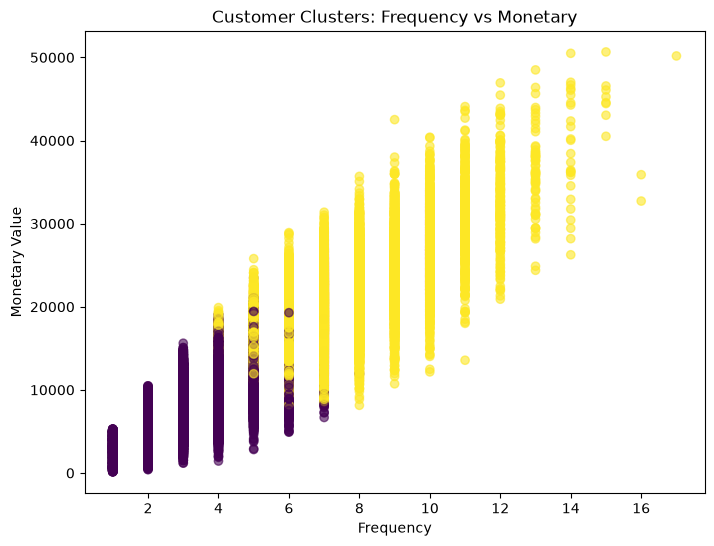

In [115]:
plt.figure(figsize=(8,6))

plt.scatter(
    rfm['frequency'],
    rfm['monetary'],
    c=rfm['cluster'],
    alpha=0.6
)

plt.title('Customer Clusters: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary Value')

plt.show()

## # Retention & Churn Analysis

## 1. Overall Churn Distribution

In [116]:
churn_counts = rfm['churn'].value_counts()

print(churn_counts)

churn
0    39732
1     9929
Name: count, dtype: int64


In [117]:
## Percentage
churn_percentage = (
    rfm['churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

churn
0    80.01
1    19.99
Name: proportion, dtype: float64


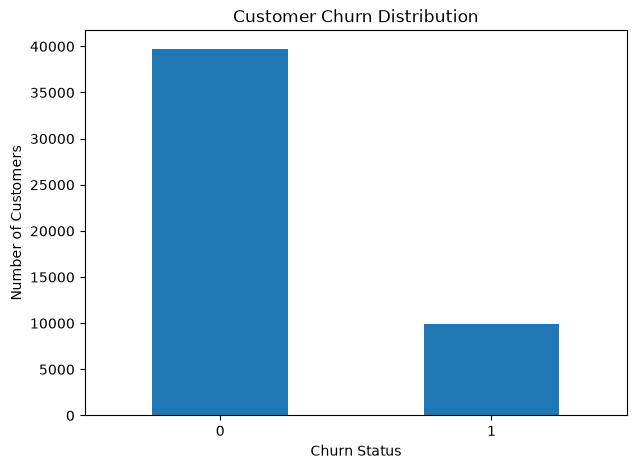

In [118]:
## Visualize 
plt.figure(figsize=(7,5))

churn_counts.plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

## 2. Churn rate by Customer Segment

In [119]:
segment_churn = (
    rfm.groupby('segment')['churn']
       .mean()
       .mul(100)
       .round(2)
       .sort_values(ascending=False)
)

print(segment_churn)

segment
Champions              20.48
Loyal Customers        20.28
Hibernating            20.28
Potential Loyalists    19.86
At Risk                19.44
Name: churn, dtype: float64


## Visualize 

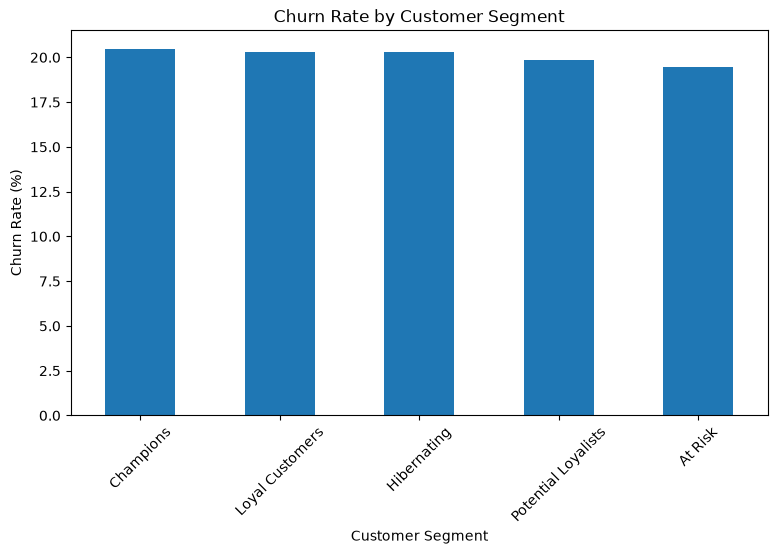

In [120]:
plt.figure(figsize=(9,5))

segment_churn.plot(kind='bar')

plt.title('Churn Rate by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)

plt.show()

## 3. Revenue at Risk from Churn

In [121]:
churned_revenue = rfm.loc[
    rfm['churn'] == 1,
    'monetary'
].sum()

total_revenue = rfm['monetary'].sum()

revenue_at_risk = (
    churned_revenue / total_revenue * 100
)

print("Churned Customer Revenue:", churned_revenue)
print(f"Revenue at Risk: {revenue_at_risk:.2f}%")

Churned Customer Revenue: 136725445
Revenue at Risk: 20.07%


## 4. Purchase Actitvity Over Time 

In [122]:
monthly_customers = (
    df.groupby('purchase_month')['customer_id']
      .nunique()
)

print(monthly_customers)

purchase_month
2020-01    5411
2020-02    5075
2020-03    5363
2020-04    5297
2020-05    5420
2020-06    5237
2020-07    5462
2020-08    5594
2020-09    5236
2020-10    5470
2020-11    5297
2020-12    5414
2021-01    5379
2021-02    4931
2021-03    5297
2021-04    5209
2021-05    5425
2021-06    5274
2021-07    5450
2021-08    5496
2021-09    5277
2021-10    5391
2021-11    5123
2021-12    5445
2022-01    5398
2022-02    4888
2022-03    5429
2022-04    5301
2022-05    5397
2022-06    5252
2022-07    5541
2022-08    5361
2022-09    5198
2022-10    5301
2022-11    5386
2022-12    5424
2023-01    5423
2023-02    4913
2023-03    5486
2023-04    5186
2023-05    5446
2023-06    5199
2023-07    5354
2023-08    5456
2023-09    2341
Freq: M, Name: customer_id, dtype: int64


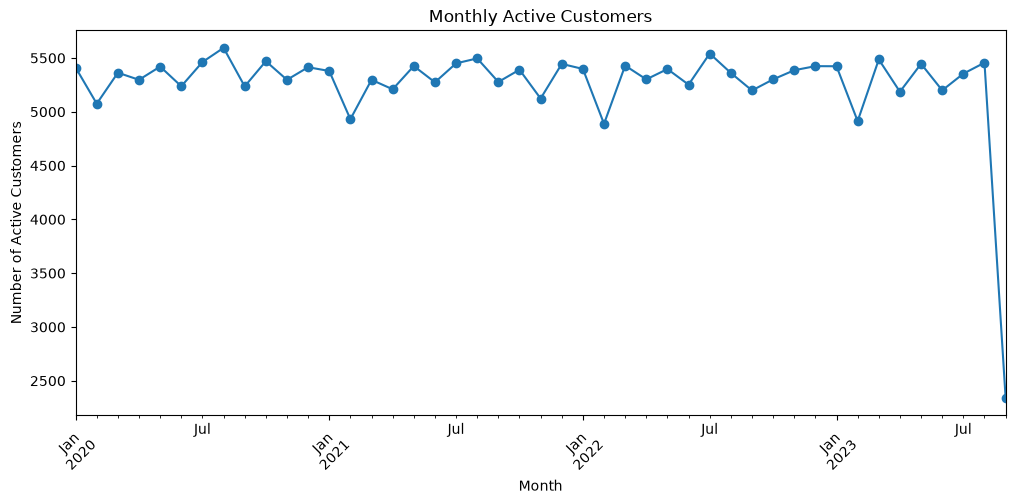

In [123]:
## Plot
plt.figure(figsize=(12,5))

monthly_customers.plot(kind='line', marker='o')

plt.title('Monthly Active Customers')
plt.xlabel('Month')
plt.ylabel('Number of Active Customers')

plt.xticks(rotation=45)

plt.show()

## 5. Monthly Revenue and Customers Together 

In [124]:
monthly_summary = df.groupby('purchase_month').agg(
    active_customers=('customer_id', 'nunique'),
    transactions=('customer_id', 'count'),
    revenue=('total_purchase_amount', 'sum')
).reset_index()

monthly_summary

,purchase_month,active_customers,transactions,revenue
0,2020-01,5411,5723,15566765
1,2020-02,5075,5364,14660710
2,2020-03,5363,5665,15517357
3,2020-04,5297,5570,15060419
4,2020-05,5420,5724,15517765
5,2020-06,5237,5512,15062859
6,2020-07,5462,5743,15575247
7,2020-08,5594,5886,16190648
8,2020-09,5236,5524,15134038
9,2020-10,5470,5757,15758325


## 6. Repeat Customer Analysis

In [125]:
repeat_customers = (rfm['frequency'] > 1).sum()

total_customers = len(rfm)

repeat_customer_rate = (
    repeat_customers / total_customers * 100
)

print(f"Repeat Customer Rate: {repeat_customer_rate:.2f}%")

Repeat Customer Rate: 96.67%


## 7. One Time vs Repeat Customers

In [126]:
rfm['customer_type'] = rfm['frequency'].apply(
    lambda x: 'One-Time Customer'
    if x == 1
    else 'Repeat Customer'
)

In [127]:
customer_type_counts = rfm['customer_type'].value_counts()

print(customer_type_counts)

customer_type
Repeat Customer      48008
One-Time Customer     1653
Name: count, dtype: int64


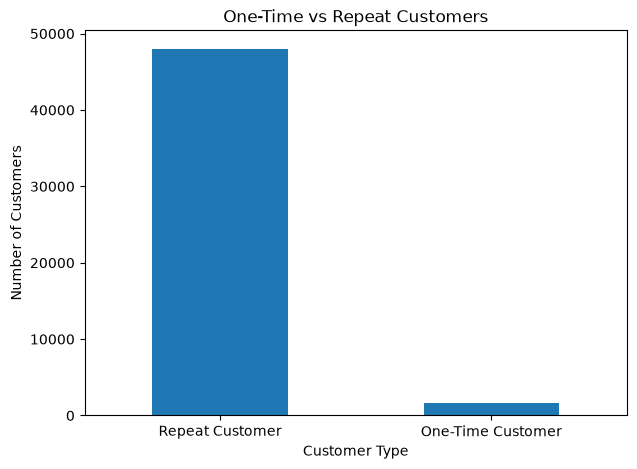

In [128]:
## Visualize 
plt.figure(figsize=(7,5))

customer_type_counts.plot(kind='bar')

plt.title('One-Time vs Repeat Customers')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

## 8. Compare Spending: One-Time vs Repeat

In [129]:
customer_type_spending = (
    rfm.groupby('customer_type')['monetary']
       .mean()
)

print(customer_type_spending)

customer_type
One-Time Customer     2745.049002
Repeat Customer      14097.832299
Name: monetary, dtype: float64


## 9. Create a Retention-Oriented Summary

In [130]:
retention_summary = rfm.groupby('customer_type').agg(
    customers=('customer_id', 'count'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    avg_recency=('recency', 'mean'),
    churn_rate=('churn', 'mean')
).round(2)

retention_summary['churn_rate'] *= 100

retention_summary

,customers,avg_frequency,avg_monetary,avg_recency,churn_rate
customer_type,,,,,
One-Time Customer,1653,1.00,2745.05,677.05,20.0
Repeat Customer,48008,5.17,14097.83,248.06,20.0


## 10. Save Your Analysis Dataset

In [131]:
rfm.to_csv('customer_rfm_segments.csv', index=False)

In [132]:
monthly_summary.to_csv('monthly_customer_summary.csv', index=False)

## # Cluster Profiling & Interpretation

## 1. Check Cluster sizes 

In [133]:
cluster_counts = rfm['cluster'].value_counts().sort_index()

print(cluster_counts)

cluster
0    26908
1    22753
Name: count, dtype: int64


In [134]:
cluster_percentage = (
    rfm['cluster']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print(cluster_percentage)

cluster
0    54.18
1    45.82
Name: proportion, dtype: float64


## 2. Create the Cluster Profile

In [135]:
cluster_profile = rfm.groupby('cluster').agg(
    customers=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    avg_order_value=('avg_order_value', 'mean'),
    avg_return_rate=('return_rate_pct', 'mean'),
    avg_customer_age=('customer_age', 'mean'),
    churn_rate=('churn', 'mean')
).round(2)

cluster_profile

,customers,avg_recency,avg_frequency,avg_monetary,avg_order_value,avg_return_rate,avg_customer_age,churn_rate
cluster,,,,,,,,
0,26908,357.14,3.48,8966.81,2623.91,59.44,43.53,0.2
1,22753,150.22,6.87,19341.07,2849.12,59.63,44.19,0.2


In [136]:
cluster_profile['churn_rate'] = (
    cluster_profile['churn_rate'] * 100
).round(2)

cluster_profile

,customers,avg_recency,avg_frequency,avg_monetary,avg_order_value,avg_return_rate,avg_customer_age,churn_rate
cluster,,,,,,,,
0,26908,357.14,3.48,8966.81,2623.91,59.44,43.53,20.0
1,22753,150.22,6.87,19341.07,2849.12,59.63,44.19,20.0


## 3. Add Revenue Contribution

In [137]:
cluster_revenue = (
    rfm.groupby('cluster')['monetary']
       .sum()
)

cluster_revenue_percentage = (
    cluster_revenue /
    cluster_revenue.sum() * 100
).round(2)

print("Cluster Revenue:")
print(cluster_revenue)

print("\nRevenue Contribution (%):")
print(cluster_revenue_percentage)

Cluster Revenue:
cluster
0    241278875
1    440067424
Name: monetary, dtype: int64

Revenue Contribution (%):
cluster
0    35.41
1    64.59
Name: monetary, dtype: float64


## 4. Visualize Cluster Size 

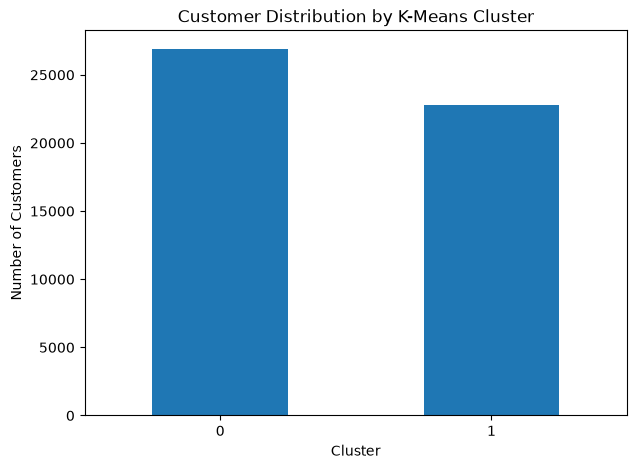

In [138]:
plt.figure(figsize=(7,5))

cluster_counts.plot(kind='bar')

plt.title('Customer Distribution by K-Means Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

## 5. Compare Recency

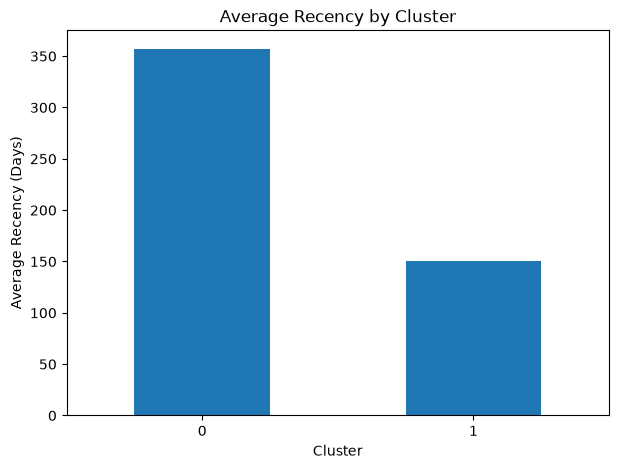

In [139]:
plt.figure(figsize=(7,5))

cluster_profile['avg_recency'].plot(kind='bar')

plt.title('Average Recency by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Recency (Days)')
plt.xticks(rotation=0)

plt.show()

## 6. Compare Frequency 

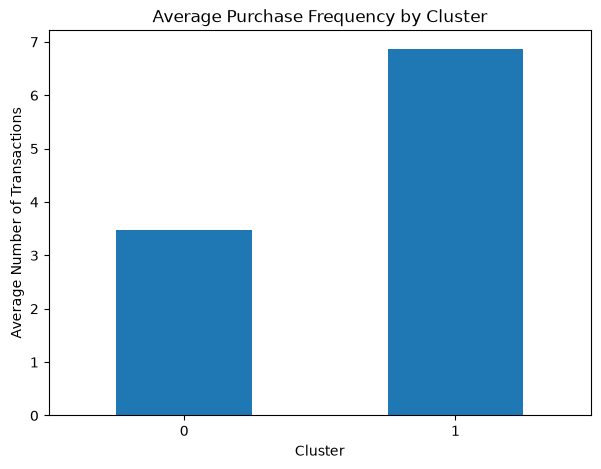

In [140]:
plt.figure(figsize=(7,5))

cluster_profile['avg_frequency'].plot(kind='bar')

plt.title('Average Purchase Frequency by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Number of Transactions')
plt.xticks(rotation=0)

plt.show()

## 7. Compare Monetary Value

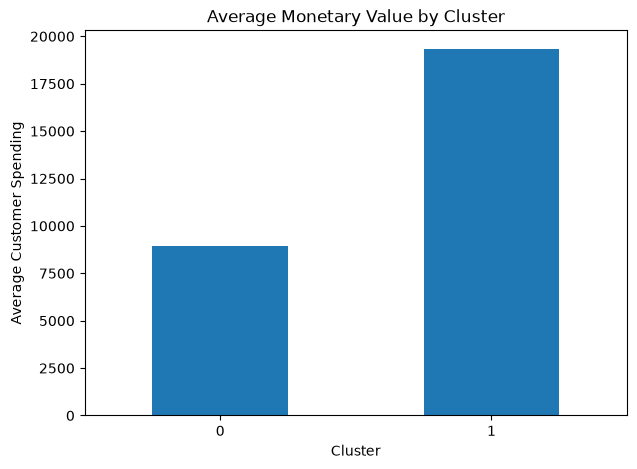

In [141]:
plt.figure(figsize=(7,5))

cluster_profile['avg_monetary'].plot(kind='bar')

plt.title('Average Monetary Value by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Customer Spending')
plt.xticks(rotation=0)

plt.show()

## 8. Create a final cluster table

In [142]:
final_cluster_profile = rfm.groupby('cluster').agg(
    customer_count=('customer_id', 'count'),
    avg_recency_days=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_spending=('monetary', 'mean'),
    avg_order_value=('avg_order_value', 'mean'),
    avg_return_rate=('return_rate_pct', 'mean'),
    churn_rate=('churn', 'mean')
).round(2)

final_cluster_profile['customer_percentage'] = (
    final_cluster_profile['customer_count'] /
    len(rfm) * 100
).round(2)

final_cluster_profile['churn_rate'] = (
    final_cluster_profile['churn_rate'] * 100
).round(2)

final_cluster_profile

,customer_count,avg_recency_days,avg_frequency,avg_spending,avg_order_value,avg_return_rate,churn_rate,customer_percentage
cluster,,,,,,,,
0,26908,357.14,3.48,8966.81,2623.91,59.44,20.0,54.18
1,22753,150.22,6.87,19341.07,2849.12,59.63,20.0,45.82


In [143]:
cluster_profile

,customers,avg_recency,avg_frequency,avg_monetary,avg_order_value,avg_return_rate,avg_customer_age,churn_rate
cluster,,,,,,,,
0,26908,357.14,3.48,8966.81,2623.91,59.44,43.53,20.0
1,22753,150.22,6.87,19341.07,2849.12,59.63,44.19,20.0


In [144]:
final_cluster_profile

,customer_count,avg_recency_days,avg_frequency,avg_spending,avg_order_value,avg_return_rate,churn_rate,customer_percentage
cluster,,,,,,,,
0,26908,357.14,3.48,8966.81,2623.91,59.44,20.0,54.18
1,22753,150.22,6.87,19341.07,2849.12,59.63,20.0,45.82


## # Connect to PostgreSQL

In [156]:
pip install psycopg2-binary sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [160]:
# Check columns having Period datatype
for col in df.columns:
    if "period" in str(df[col].dtype).lower():
        print(col, df[col].dtype)

purchase_month period[M]


In [162]:
print(df.dtypes)

customer_id                       int64
purchase_date            datetime64[us]
product_category                    str
product_price                     int64
quantity                          int64
total_purchase_amount             int64
payment_method                      str
customer_age                      int64
returns                         float64
customer_name                       str
gender                              str
churn                             int64
purchase_month                      str
dtype: object


In [161]:
# Convert Period columns to string
for col in df.columns:
    if "period" in str(df[col].dtype).lower():
        df[col] = df[col].astype(str)

print("Period columns converted successfully.")

Period columns converted successfully.


In [163]:
df.to_sql(
    "customer",
    engine,
    if_exists="replace",
    index=False
)

print("Data successfully loaded into PostgreSQL!")

Data successfully loaded into PostgreSQL!


In [165]:
from sqlalchemy import create_engine
# Step 1 : Connect to PostgreSQL
# PostgreSQL connection details
username = "postgres"
password = "8210"
host = "localhost"
port = "5432"
database = "customer_behaviour_analysis"

# Create connection
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Upload DataFrame to PostgreSQL
table_name = "customer"

df.to_sql(table_name,engine,if_exists="replace",index=False)

print(f"Data successfully loaded into table '{table_name}'.")

Data successfully loaded into table 'customer'.
